# Exercise 2 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

# Linear Programming exercise

In [3]:
### Do the imports -- no need to change this
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

In [61]:
reward_mode = 2 # see below to visualize the reward function
size = 3 # size of the gridworld (3x3)
prop = 0.1 # proportion of randomly taken steps due to noise in the environment 
gamma=0.99 # discount factor

gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
print('Reward function: \n', gridworld.r) # visualize the reward function

Reward function: 
 [[   0.    0.    0.    0.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [-100. -100. -100. -100.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]]


We will use a solver to compute the **optimal value function** to measure the suboptimality of the policies produced by our algorithms.

To access the optimal value function use `solver.v`.

In [62]:
solver = MDPsolver(gridworld) # call the MDPsolver class
solver.value_iteration() # call the value iteration method to find V^* once

# Ex 1: Solving the Primal [20 points]

We will leverage the powerful `scipy` library to solve **Linear Programs (LPs)**. Below we give an example of using the [linprog module](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linprog.html) to solve a simple LP:

\begin{aligned}
 & \min_{x := \begin{bmatrix}
x_0  \\
x_1
\end{bmatrix}  \in \mathbb{R}^2}  \begin{bmatrix}
-1  \\
4
\end{bmatrix} ^\top x
\\&  \text{s.t.}  \begin{bmatrix}
-3 & 1 \\
1 & 2 
\end{bmatrix} \mathbb{x} \le  \begin{bmatrix}
6  \\
4 
\end{bmatrix} , \quad  x_1\ge -3 \,.
\end{aligned}

The **code example below will be instructive** when you later construct the LP corresponding to the MDP.

In [63]:
from scipy.optimize import linprog # import the linear programming solver from scipy

# Note that the bounds argument in linprog is a  sequence of (min, max) pairs for each element in x, defining the minimum and maximum values.
x0_bounds = (None, None)
x1_bounds = (-3, None)

# call linear programming solver:
res = linprog([-1, 4], 
              A_ub=[[-3, 1], [1, 2]], 
              b_ub=[6, 4], 
              bounds=[x0_bounds, x1_bounds],
              method="simplex")
print('The solution is ', res.x) # access and print the solution
print(res.message) # print the message of the solver (e.g., terminated successfully)

The solution is  [10. -3.]
Optimization terminated successfully.


/var/folders/3r/zftwt15d1xjg4jt1nztmv7p40000gn/T/ipykernel_94642/2674117054.py:8: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  res = linprog([-1, 4],


Now we are ready to use `linprog` to solve the LP problem in gridworld.

We define a distribution `mu` over the states.

In [64]:
mu = np.ones((gridworld.n_states,1))/gridworld.n_states # initialize mu

Next, we need to **instantiate the constraints of the primal problem**. Notice that `scipy` requires the inequality constraints in the form $A_{ub} x \leq b_{ub}$.


To this end, we rewrite the constraint $EV \geq \gamma P V + r$ in the form expected by `scipy`.

In [65]:
def build_matrix(env):
    E = np.kron(np.eye(env.n_states), np.ones(env.n_actions)).T # build the matrix E
    P = env.T.transpose((1,0,2)).reshape(env.n_states*env.n_actions, -1) # build the matrix P
    return env.gamma*P - E

(Side remark: The indexing in the matrices `E` and `P` here is slightly different from the one in the lecture. This does not change any of the formulas from the slides since both matrices are indexed in the same way, consistently throughout this exercise. You may ignore this comment.)

Then, use the function `linprog` of `scipy` to solve the dual problem and show that you can retrieve the same $V^\star$ computed with the solver and stored in `solver.v`

In [66]:
# Call linear programming solver with the correct inputs:
primal_out = linprog((1 - gridworld.gamma)*mu.flatten(), 
                     A_ub=build_matrix(gridworld), 
                     b_ub=-gridworld.r.reshape(gridworld.n_states*gridworld.n_actions),
                     method="simplex",
                     bounds=[(None, None)] * gridworld.n_states)

/var/folders/3r/zftwt15d1xjg4jt1nztmv7p40000gn/T/ipykernel_94642/1641668414.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  primal_out = linprog((1 - gridworld.gamma)*mu.flatten(),


(*Hint:* Check slide 23 for the matrix form (or slide 8), lecture 3 to recall the primal.)

We can access the solution of the primal LP using `primal_out.x`. Compare the error with the value of `solver.v`.

In [67]:
np.linalg.norm(primal_out.x - solver.v) # plot 2-norm

np.float64(4.111484296790486e-14)

***Question***

By running the following two cells, plot (in matrix form) `mu` and the difference between `solver.v` and `primal_out.x`. Then, answer the following question: Can we ensure that `np.linalg.norm(primal_out.x - solver.v)` is zero (up to numerical errors) for the current value of `mu`? 

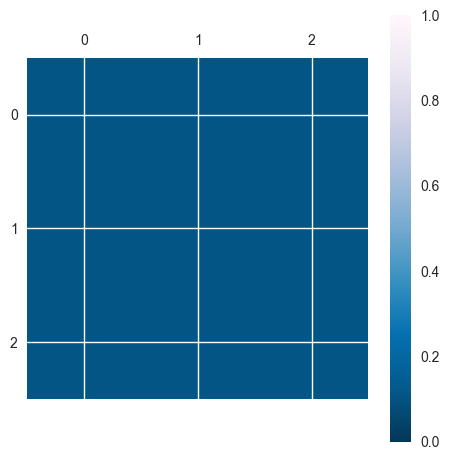

In [68]:
plt.matshow(mu.reshape(size, size), cmap='PuBu_r', vmin=0,vmax=1) # plot distribution mu over states 
plt.colorbar()

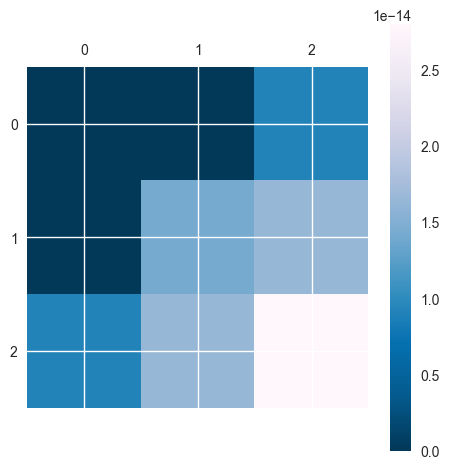

In [69]:
plt.matshow((solver.v - primal_out.x).reshape(size, size), cmap='PuBu_r') # plot the difference between the value function and the solution of the linear program
plt.colorbar()

**Answer**

Yes, for the uniform `mu` (which is >0 on all states), the primal LP has a unique optimal solution equal to $V^\star$. The key result (Lemma, Slide 10) states that $V^\star$ is the **unique** optimal solution to the primal LP for any strictly positive weights $\{\mu(s)> 0\}$. Since uniform $\mu$ assigns positive weight to every state, the LP optimizer must equal $V^\star$, so the difference is zero up to numerical precision of the simplex solver.

Next, we repeat the same experiment with a different value of `mu`. 

Note that we do **not** overwrite `mu` or `primal_out` (but instead have `mu2` and `primal_out2`, since for all other exercises, we will use the original, uniform `mu`.)

In [70]:
# overwrite mu with a new distribution:
mu2 = np.zeros((gridworld.n_states,1))
mu2[-3] = 1

Fill in the following, as before but for the distribution `mu2`.

In [71]:
# solve the LP with the new mu2:
primal_out2 = linprog((1 - gridworld.gamma) * mu2.flatten(), 
                      A_ub=build_matrix(gridworld), 
                      b_ub=-gridworld.r.reshape(gridworld.n_states*gridworld.n_actions),
                      method="simplex",
                      bounds=[(None, None)]* gridworld.n_states)

/var/folders/3r/zftwt15d1xjg4jt1nztmv7p40000gn/T/ipykernel_94642/4192607101.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  primal_out2 = linprog((1 - gridworld.gamma) * mu2.flatten(),


We compare with the value computed by Value Iteration `solver.v`.

In [72]:
np.linalg.norm(primal_out2.x - solver.v) # plot 2-norm

np.float64(2.772246430099758)

Note that now, the optimal solution of the primal LP `primal_out2.x` and the optimal value function `solver.v` do not coincide anymore! 

This is despite the fact that the optimal value function `solver.v` was computed **right in the beginning**, before we even initialized the `mu` for solving the LP the first time. So `solver.v` is definitely the correct optimal value function for each state.

**Question:**

Why does it make sense that the two values do not coincide?

**Answer:**

With `mu2` a point mass on a single state, we have $\mu_2(s) = 0$ for all but one state. The LP objective $(1-\gamma)\langle\mu_2, V\rangle$ only "cares about" minimising $V$ at the single supported state; the values $V(s)$ at states where $\mu_2(s) = 0$ have zero influence on the objective. The LP therefore has multiple optimal solutions. Any $V$ that equals $V^\star$ at the supported state but is *lower* than $V^\star$ at unsupported states is still feasible and achieves the same objective value. The simplex solver may return one of these alternative optima, which need not equal $V^\star$ globally.

**CHECK W MATTEAS ANSWER**

***Question***

We plot again in matrix form `mu2`, `solver.v` and `primal_out2.x`. Then answer the following: What can happen in the states where `mu2 = 0`?

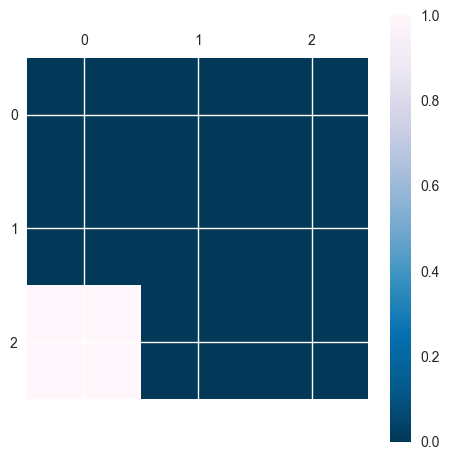

In [73]:
plt.matshow(mu2.reshape(size, size), cmap='PuBu_r', vmin=0,vmax=1) # plot distribution mu over states
plt.colorbar()

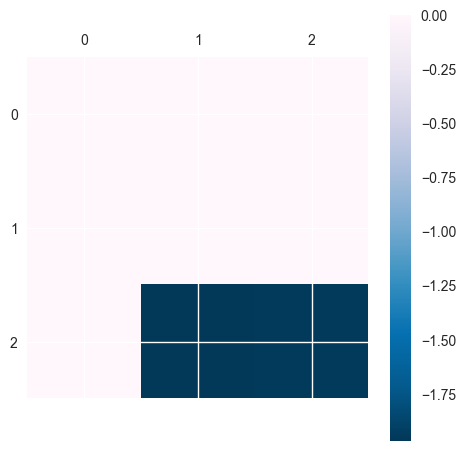

In [74]:
plt.matshow((solver.v - primal_out2.x).reshape(size, size), cmap='PuBu_r') # plot the difference between the value function and the solution of the linear program
plt.colorbar()

**Answer:**

At states with $\mu_2(s) = 0$, the LP objective is indifferent to the value $V(s)$. Subject only to the Bellman inequality constraints, the LP can push $V(s)$ *below* $V^\star(s)$ at those states. Indeed, $V^\star$ is the minimal feasible point in the sense of the $\mu$-weighted objective, but where $\mu_2(s) = 0$ this pressure disappears entirely. Concretely, the solver may return values strictly less than $V^\star(s)$ at unweighted states — the constraints $V(s) \geq r(s,a) + \gamma\sum_{s'}P(s'|s,a)V(s')$ are still satisfied, but the global pointwise floor imposed by the positive-weight case is no longer enforced. $V^\star$ is still feasible (the Bellman inequality constraints still hold) but it is no longer the unique minimiser, since the objective does not penalize deviations from $V^\star$ an unweighted states.


# Ex 2: Solving the Dual [20 points]

Try now to solve the dual using again the `linprog` routine of scipy. 

Note that we did **not** overwrite `mu` (i.e. it is still uniform, and `primal_out.x` is the primal solution for this `mu`).

(*Hint:* Check slide 23 for the matrix form (or slide 11), lecture 3 to recall the dual.)

In [41]:
# solve the dual LP with the correct inputs:
dual_out = linprog(-gridworld.r.reshape(gridworld.n_states * gridworld.n_actions), 
              A_eq= build_matrix(gridworld).T, 
              b_eq= -(1 - gridworld.gamma)*mu,
              method="simplex",
              bounds=[(0, None)]*gridworld.n_states*gridworld.n_actions)

/var/folders/3r/zftwt15d1xjg4jt1nztmv7p40000gn/T/ipykernel_94642/2026896104.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  dual_out = linprog(-gridworld.r.reshape(gridworld.n_states * gridworld.n_actions),


We verify that **strong duality** holds:

In [75]:
dual_value = dual_out.x.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions)) # compute the optimal value of the dual
primal_value = (1 - gridworld.gamma)*primal_out.x.dot(mu)[0] # compute the optimal value of the primal
abs(primal_value - dual_value) # print the absolute difference between the primal and dual optimum

np.float64(8.326672684688674e-17)

Note that the solution of the dual problem gives us the **optimal occupancy measure**. Given this:

1. Obtain the **greedy policy** given the solution of the primal problem.

2. **Evaluate** this policy and **compare** the obtained values with the solution of the dual problem.

In [76]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            action_taken = pi[s]
            v[s] = q[s,action_taken]
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

In [77]:
pi = dual_out.x.reshape(gridworld.n_states,gridworld.n_actions).argmax(axis=1) # side remark/explanation: We know a deterministic optimal policy exists. It turns out that we can find it by checking for which component a lambda_opt(s,a) is > 0, and then setting pi_opt(a|s) = 1 for that action.
v,q = evaluate_policy(pi,gridworld) # evaluate the policy
print(np.linalg.norm(v-primal_out.x)) # print the 2-norm between the value function and the solution of the primal LP

4.111484296790486e-14


***Questions***

Derive the dual from the primal. That is, show that it indeed the dual linear program of the primal program (and that thus the values coincide by strong duality).

(*Hint:* You may consult the supplementary material of lecture 3, slide 9 and 10 in the appendix to read about strong duality in LPs. Make sure to explain step by step why it works.)

***Answer:***

We derive the dual LP (D) from the primal LP (P) using standard Lagrangian duality.

**1. Primal in Lagrangian form**

The primal LP is:
$$\min_{V \in \mathbb{R}^{|S|}}\ (1-\gamma)\langle\mu, V\rangle \quad \text{s.t.} \quad (E - \gamma P)V \geq r.$$

Equivalently, written as $(\gamma P - E)V \leq -r$. We introduce a dual variable $\lambda \geq 0$ for each inequality constraint (one per state-action pair). The Lagrangian is:
$$\mathcal{L}(V, \lambda) = (1-\gamma)\mu^\top V + \lambda^\top\bigl((\gamma P - E)V - (-r)\bigr) = (1-\gamma)\mu^\top V + \lambda^\top(\gamma P - E)V + \lambda^\top r = ((1-\gamma)\mu + (\gamma P - E)^\top \lambda)^\top V + \lambda^\top r$$

We note that the Lagrangian is affine in $V$ and for simplicity we call $c(\lambda) = ((1-\gamma)\mu + (\gamma P - E)^\top \lambda)$ the coefficient of $V$.

**2. Dual function**

The dual function is $g(\lambda) = \min_V \mathcal{L}(V, \lambda)$. Since $\mathcal{L}$ is affine in $V$ and $V$ is unconstrained in $\mathbb{R}^{|S|}$, the minimum over $V$ is $-\infty$ unless the coefficient of $V$ $c(\lambda)$ is zero, in which case:
$$(1-\gamma)\mu + (\gamma P - E)^\top \lambda = 0 \quad \Longleftrightarrow \quad (E^\top - \gamma P^\top)\lambda = (1-\gamma)\mu \quad \Longleftrightarrow \quad E^\top\lambda = (1-\gamma)\mu + \gamma P^\top\lambda$$

If this stationarity condition holds, $g(\lambda) = \lambda^\top r = \langle \lambda, r\rangle$.

**3. Dual problem**

The dual maximizes the dual function $g(\lambda)$ over $\lambda \geq 0$:
$$\max_{\lambda \geq 0}\ \langle \lambda, r\rangle \quad \text{s.t.} \quad E^\top\lambda - \gamma P^\top\lambda = (1-\gamma)\mu,$$
which gives us exactly the dual LP (D) on Slide 23 in the lecture. 

**4. Strong duality.**

Both the primal and dual LPs are feasible ($V^\star$ is primal feasible by the Bellman inequality, Slide 8; $\lambda^{\pi^\star}$ is dual feasible by the occupancy measure characterisation, Slide 15) and bounded (the rewards are bounded, so the objectives are finite). By the Strong Duality Theorem (Slide 3, supplementary material), both attain their optima and the optimal values coincide:
$$(1-\gamma)\langle \mu, V^\star\rangle = \langle \lambda^\star, r\rangle.$$

We confirm this also numerically by observing a zero value (up to numerical precision) of `abs(primal_value-dual_value)`.

# Ex 3: Implement REPS with known dynamics [20 points]

In this exercize you will **implement the REPS algorithm** as we have seen in the lectures.
Namely, recall the following **details of the algorithm**:

1. **Initialization** (uniform): $\forall s, a, \lambda_0(s,a) = \frac{1}{|\mathcal{S}||\mathcal{A}|}$;

2. **REPS loss computation**: $\mathcal{L}(\lambda, V) = (1-\gamma) \langle \mu, V \rangle + \frac{1}{\eta}\log{\langle \lambda, \exp{(\eta(r+\gamma P V - E V))} \rangle}$;

3. **Solving for the values**: $V_{k}=\text{argmin}_{V}~{\mathcal{L}(\lambda_k, V)}$, for this we will use the `minimize` function from `scipy.optimize`;

4. **Updating the occupancy measure:** $\lambda_{k+1} \propto \lambda_k \cdot \exp{(\eta (r+\gamma P V_{k} - E V_{k}))}$ (unnormalized, you then must make sure it sums to 1 in every step).

In [78]:
from scipy.optimize import minimize
from scipy.special import logsumexp, softmax
from plot import plot_log_lines, plot_lines

In [95]:
def reps_loss(lambda_, V, eta, initial): # return the reps loss
    delta = gridworld.r.reshape(gridworld.n_states * gridworld.n_actions) + build_matrix(gridworld).dot(V)
    loss = (1 - gridworld.gamma) * initial.flatten().dot(V) + (1 / eta) * logsumexp(eta * delta, b = lambda_)
    return loss

def minimize_reps_loss(lambda_, eta, initial): # find minimizer of the reps loss
    loss = lambda V : reps_loss(lambda_, V, eta, initial)
    V = minimize(loss, np.zeros(gridworld.n_states), method = "CG", options={'maxiter': 1000})
    return V.x

In [82]:
K = 40 # number of iterations
mu = np.ones((gridworld.n_states,1))/gridworld.n_states # initialize mu again to the uniform distribution (not needed, just to be safe)

#initialize the variables
subopts = []
feasibility_errors = []
lambda_ = np.ones(gridworld.n_states*gridworld.n_actions)/gridworld.n_states/gridworld.n_actions
iterates = [lambda_]
subopts.append(-lambda_.T.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions))+(1-gridworld.gamma)*mu.T.dot(solver.v)[0])
feasibility_error = np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1-gridworld.gamma)*mu)
feasibility_errors.append(feasibility_error)

# REPS: iterate over K steps
for k in range(K):
    eta = 1/np.sqrt(k+1) # set the step size
    
    V = minimize_reps_loss(lambda_, eta, mu) # minimize the reps loss
    delta = gridworld.r.reshape(gridworld.n_states*gridworld.n_actions) + build_matrix(gridworld).dot(V) # compute the advantage function
    
    new_lambda_ = lambda_ * np.exp(eta * delta) # update the lambda
    new_lambda_ /= np.sum(new_lambda_) # normalize the lambda_
    lambda_ = new_lambda_
    
    # store the suboptimality and feasibility errors:
    subopt = -lambda_.T.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions))+(1-gridworld.gamma)*mu.T.dot(solver.v)[0]
    feasibility_error = np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1-gridworld.gamma)*mu)
    subopts.append(subopt)
    feasibility_errors.append(feasibility_error)
    iterates.append(lambda_)

**Plot of the suboptimality of iterates produced by REPS**

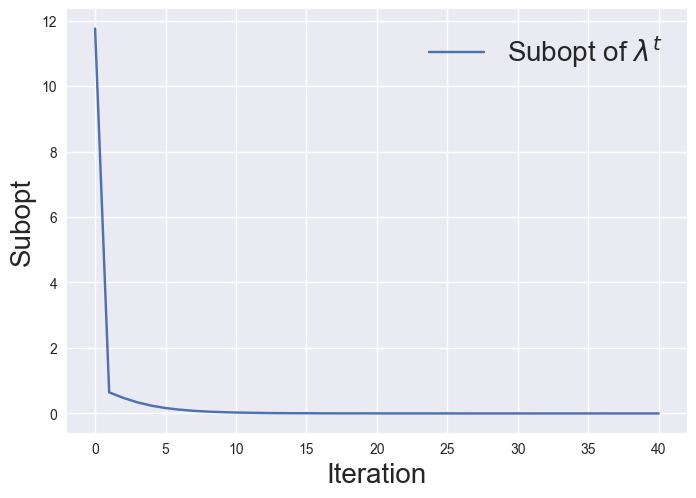

In [83]:
plot_lines([np.array(subopts)], [r"Subopt of $\lambda^t$"], ["Iteration", "Subopt"], "figs", "subopts.pdf", show = True)

**Theoretical Derivation of REPS**

Prove that the iterates of REPS are equivalent to the iterates produced by the following updates:

$$ \lambda_{k+1} = \mathrm{argmax}_{\lambda} \left( \langle \lambda, r \rangle - \frac{1}{\eta} \left\langle \lambda,~ \log\left(\frac{\lambda}{\lambda_k}\right) \right\rangle \right) \quad \text{s.t.} \quad E^T \lambda = \gamma P^T \lambda + (1 - \gamma) \mu. $$

(*Hint:* Check the slides of lecture if you do not know where to start.)

**Answer:**

We show that the REPS update $\lambda_{k+1} \propto \lambda_k \odot \exp\!\bigl(\eta(r + \gamma PV_k - EV_k)\bigr)$ is equivalent to the stated proximal point problem on the dual LP.

**1. Proximal point on the dual**

Following Slides 35–37, we apply the proximal point method with KL Bregman divergence to the dual LP. Dualising the flow constraint with multiplier $V$ and adding the KL proximity term centred at $\lambda_{k-1}$, the $k$-th proximal point update is:
$$\lambda_k = \operatorname{argmax}_{\lambda \in \Delta}\ \min_V\ \Bigl[\langle\lambda, r\rangle + \langle V,\ \gamma P^\top\lambda - E^\top\lambda + (1-\gamma)\mu\rangle - \frac{1}{\eta}D_\mathrm{KL}(\lambda \| \lambda_{k-1})\Bigr].$$

This is exactly the update
$$\lambda_{k+1} = \operatorname{argmax}_\lambda \Bigl(\langle\lambda, r\rangle - \frac{1}{\eta}\Bigl\langle\lambda,\ \log\frac{\lambda}{\lambda_k}\Bigr\rangle\Bigr) \quad \text{s.t.} \quad E^\top\lambda = \gamma P^\top\lambda + (1-\gamma)\mu,$$
since $D_\mathrm{KL}(\lambda\|\lambda_k) = \langle\lambda, \log(\lambda/\lambda_k)\rangle$ for distributions in the simplex.

**2. Closed-form inner solution in $\lambda$**

For any fixed $V$, the optimality (KKT) conditions for the inner $\lambda$-maximisation give (Slide 37):
$$r(s,a) + \gamma(PV)(s,a) - (EV)(s,a) - \frac{1}{\eta}\nabla_\lambda D_\mathrm{KL}(\lambda_k^V, \lambda_{k-1})\big|_{(s,a)} = 0.$$

Solving explicitly:
$$\lambda_k^V(s,a) = \frac{\lambda_{k-1}(s,a)\exp\!\bigl(\eta\,[r(s,a)+\gamma(PV)(s,a)-(EV)(s,a)]\bigr)}{\sum_{s',a'}\lambda_{k-1}(s',a')\exp\!\bigl(\eta\,[r(s',a')+\gamma(PV)(s',a')-(EV)(s',a')]\bigr)}.$$

**3.Unconstrained problem in $V$**

We substitute $\lambda_k^V$ back into the Lagrangian and we observe that the saddle-point problem reduces to the unconstrained minimization over $V$ alone (Slide 38):
$$V_k = \operatorname{argmin}_V\ (1-\gamma)\langle\mu, V\rangle + \frac{1}{\eta}\log\sum_{s,a}\lambda_{k-1}(s,a)\exp\!\bigl(\eta\,[r(s,a)+\gamma(PV)(s,a)-(EV)(s,a)]\bigr).$$

**4. Occupancy measure update**

Given $V_k$, the update follows directly from Step 2 with $V = V_k$:
$$\lambda_k(s,a) \propto \lambda_{k-1}(s,a)\cdot\exp\!\bigl(\eta\,(r + \gamma PV_k - EV_k)(s,a)\bigr)$$
which is exactly the REPS occupancy measure update.

**Plot the constraints violation**

Plot the value of $||(E^T - \gamma P^T)\lambda - (1 - \gamma) \mu || $, varying the parameter `maxiter` of the `scipy.minimize` function.

(To be clear: in the code above, modify this line ```minimize(loss, np.zeros(gridworld.n_states), method = "CG", options={'maxiter': 1000})``` and plot for varying `maxiter`.)

In [100]:
# you may use this cell to experiment with the parameter and keep the one above the same if it helps you to keep the overview
def minimize_reps_loss(lambda_, eta, initial): # find minimizer of the reps loss
    loss = lambda V : reps_loss(lambda_, V, eta, initial)
    V = minimize(loss, np.zeros(gridworld.n_states), method = "CG", options={'maxiter': 2000})
    return V.x

K = 100 # number of iterations
mu = np.ones((gridworld.n_states,1))/gridworld.n_states # initialize mu again to the uniform distribution (not needed, just to be safe)

#initialize the variables
subopts = []
feasibility_errors = []
lambda_ = np.ones(gridworld.n_states*gridworld.n_actions)/gridworld.n_states/gridworld.n_actions
iterates = [lambda_]
subopts.append(-lambda_.T.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions))+(1-gridworld.gamma)*mu.T.dot(solver.v)[0])
feasibility_error = np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1-gridworld.gamma)*mu)
feasibility_errors.append(feasibility_error)

# REPS: iterate over K steps
for k in range(K):
    eta = 1/np.sqrt(k+1) # set the step size
    
    V = minimize_reps_loss(lambda_, eta, mu) # minimize the reps loss
    delta = gridworld.r.reshape(gridworld.n_states*gridworld.n_actions) + build_matrix(gridworld).dot(V) # compute the advantage function
    
    new_lambda_ = lambda_ * np.exp(eta * delta) # update the lambda
    new_lambda_ /= np.sum(new_lambda_) # normalize the lambda_
    lambda_ = new_lambda_
    
    # store the suboptimality and feasibility errors:
    subopt = -lambda_.T.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions))+(1-gridworld.gamma)*mu.T.dot(solver.v)[0]
    feasibility_error = np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1-gridworld.gamma)*mu)
    subopts.append(subopt)
    feasibility_errors.append(feasibility_error)
    iterates.append(lambda_)

<>:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/3r/zftwt15d1xjg4jt1nztmv7p40000gn/T/ipykernel_94642/753964536.py:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  plot_lines([np.array(feasibility_errors)], [r"Constraints violation"], ["Iteration", "$|| (E^T - \gamma P^T)\lambda - (1 - \gamma) \mu ||$"], "figs", "constraints.pdf", show = True)


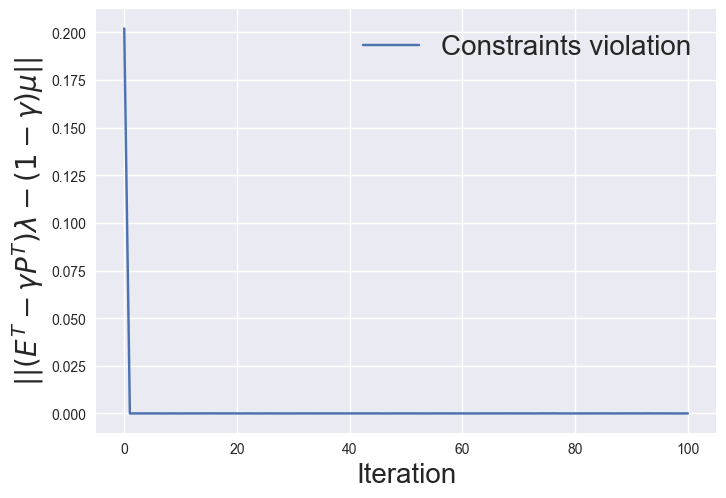

In [101]:
plot_lines([np.array(feasibility_errors)], [r"Constraints violation"], ["Iteration", "$|| (E^T - \gamma P^T)\lambda - (1 - \gamma) \mu ||$"], "figs", "constraints.pdf", show = True)

**Question**

Empirically, is the value of $||(E^T - \gamma P^T)\lambda - (1 - \gamma) \mu || $ higher for high or low values of `maxiter`?

Explain why this is the case.

**Answer:**

The constraint violation $\|(E^\top - \gamma P^\top)\lambda^k - (1-\gamma)\mu\|$ is **higher for low values**  of `maxiter`.

The inner minimization of the REPS loss over $V$ is solved approximately via the conjugate gradient (CG) method. With few CG iterations, $V_k$ is far from the true minimiser $V_k^\star$, so the resulting update $\lambda_k \propto \lambda_{k-1}\exp(\eta(r + \gamma PV_k - EV_k))$ is not the true proximal point iterate. By the KKT argument in Step 2 in the answer above, the flow constraint $(E^\top - \gamma P^\top)\lambda_k = (1-\gamma)\mu$ is satisfied **exactly** only when $V_k$ is the exact minimizer of the REPS loss. With an approximate $V_k$, the gradient stationarity condition is only approximately satisfied, and the constraint violation scales with the suboptimality $\|V_k - V_k^\star\|$. More CG iterations reduce this error, so higher `maxiter` leads to lower constraint violation.

**Question:**

Strictly speaking, are the actual iterates $\lambda_k$ in the implementation above valid occupancy measures? In other words, is $E^T \lambda_k = \gamma P^T \lambda_k + (1 - \gamma) \mu$ strictly satisfied for all iterates? Explain why this is (not) the case.

**Answer:**

Strictly speaking, **no**, the iterates $\lambda_k$ are not valid occupancy measures unless the inner minimisation is solved exactly.

A valid occupancy measure for some policy $\pi$ must satisfy the flow balance constraint $E^\top\lambda = \gamma P^\top\lambda + (1-\gamma)\mu$ (Slide 15). This equality holds for $\lambda_k$ only if $V_k$ is the *exact* minimiser of the REPS loss, since the KKT stationarity condition for the inner problem is exactly this flow balance. With finite `maxiter`, the CG solver produces an approximate $V_k$, so the stationarity condition is not exactly met, and $\lambda_k$ violates the flow constraint by an amount proportional to the inner optimisation error. Therefore, for any finite `maxiter`, $\lambda_k$ is only an **approximate** occupancy measure, with the quality of the approximation improving as `maxiter` increases.

**Plot of the suboptimality of the policies extracted from the $\lambda^k$'s**

*Extract the policies from the $\lambda^k$-iterates:* $$\pi_{\lambda^k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda_k(s,a)}.$$

In [84]:
def extract_policies_from_occ_measures(occ_measures): # extract the policies from the occupancy measures
    policies = []
    for occ_measure in occ_measures:
        policy = np.zeros((gridworld.n_states, gridworld.n_actions)) # initialize the policy
        occ_measure = occ_measure.reshape(gridworld.n_states, -1) # reshape the occupancy measure
        states_occ_measure = occ_measure.sum(axis=1) # compute the occupancy measure over states (not state-action pairs)
        for s in range(gridworld.n_states):
            policy[s] = occ_measure[s]/states_occ_measure[s] if states_occ_measure[s]>0 else np.ones(gridworld.n_actions)/gridworld.n_actions # compute the policy
        policies.append(policy)
        
    return policies

In [85]:
policies = extract_policies_from_occ_measures(iterates)

*Extract the occupancy measures from the policies:* $$ \lambda_{\pi_{\lambda^k}}(s,a) = (1 - \gamma)\sum^{\infty}_{t=0} \gamma^t \mathbb{P}[s_t=s,a_t=a | s_0 \sim \mu, \pi_{\lambda^k}].$$

In [86]:
def extract_occ_measures_from_policies(policies): # extract the occupancy measures from the policies (we do not require you to follow this)
    occ_measures = []
    for policy in policies:
        v = - (1 - gridworld.gamma)*(mu.repeat(gridworld.n_actions,axis=1)*policy).reshape(gridworld.n_states*gridworld.n_actions)
        matrix = np.eye(gridworld.n_states*gridworld.n_actions)
        T_pi = np.expand_dims(gridworld.T.transpose((1,0,2)),axis=3).repeat(gridworld.n_actions, axis=3)
        pi_tensor = np.expand_dims(policy, axis=(0,1)).repeat(T_pi.shape[0], axis=0).repeat(T_pi.shape[1], axis=1)
        T_pi = T_pi*pi_tensor
        matrix = gridworld.gamma*T_pi.reshape(gridworld.n_states*gridworld.n_actions,gridworld.n_states*gridworld.n_actions)- matrix
        occ_measure = np.linalg.solve(matrix.T, v)
        occ_measures.append(occ_measure)
    return occ_measures

In [87]:
occ_measures = extract_occ_measures_from_policies(policies)

*Check whether $\lambda_{\pi_{\lambda_k}} = \lambda_k$*:

In [88]:
# compute the difference between the occupancy measures and the iterates
diff_occ_measures = [np.linalg.norm(occ_measure - iterate) for occ_measure, iterate in zip(occ_measures, iterates)] 

<>:2: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:2: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/3r/zftwt15d1xjg4jt1nztmv7p40000gn/T/ipykernel_94642/539361456.py:2: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plot_lines([np.array(diff_occ_measures), np.array(feasibility_errors)/(1 - gridworld.gamma)], [r"Diff. Occupancy measures", r"$(1-\gamma)^{-1}\cdot$ Constraints violation"], ["Iteration", "$|| \lambda - \lambda_{\pi_\lambda}||$"], "figs", "diff_occ_measures.pdf", show = True)


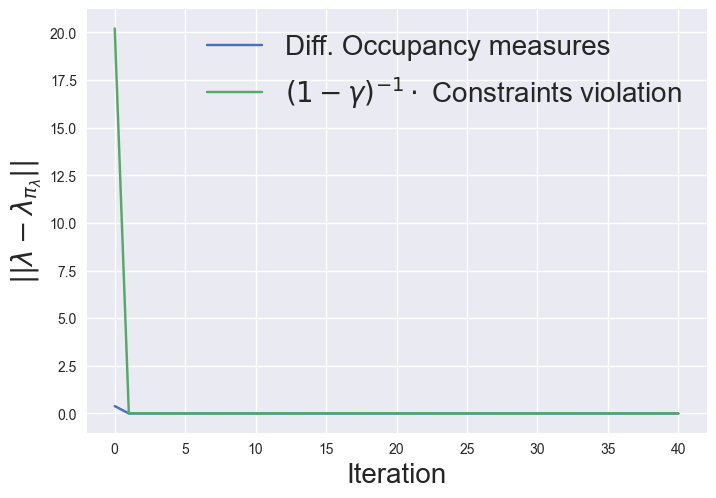

In [89]:
# plot the difference between the occupancy measures and the iterates
plot_lines([np.array(diff_occ_measures), np.array(feasibility_errors)/(1 - gridworld.gamma)], [r"Diff. Occupancy measures", r"$(1-\gamma)^{-1}\cdot$ Constraints violation"], ["Iteration", "$|| \lambda - \lambda_{\pi_\lambda}||$"], "figs", "diff_occ_measures.pdf", show = True)

**Questions**

- How does the norm of the difference $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ relate to the constraint violation $|| (E^T - \gamma P^T)\lambda^k - (1 - \gamma) \mu ||$ ?

- If $|| (E^T - \gamma P^T)\lambda^k - (1 - \gamma) \mu ||$ is small, can you conclude that $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ is also small ? 

*Hint: For both, you can answer leveraging the result in Lemma 3 of https://arxiv.org/pdf/2112.14004.pdf*

- As a consequence how is $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ affected by the value of `maxiter`?

*Hint:* Recall your empirical finding about the impact of `maxiter` (above).

***Answer:***

1. **Relation to constraint violation**

By Lemma 3, the difference between $\lambda^k$ and the true occupancy measure of the policy it induces satisfies:
$$\|\lambda^k - \lambda_{\pi_{\lambda^k}}\| \leq \frac{1}{1-\gamma}\|(E^\top - \gamma P^\top)\lambda^k - (1-\gamma)\mu\|.$$
So $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ is bounded by $\frac{1}{1-\gamma}$ times the constraint violation. The plot confirms this: the two curves track each other with the $(1-\gamma)^{-1}$ scaling factor.

2. **If constraint violation is small, is $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ also small?**

Yes. If $\|(E^\top - \gamma P^\top)\lambda^k - (1-\gamma)\mu\| \leq \delta$, then by the lemma above $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\| \leq \frac{\delta}{1-\gamma}$. Small constraint violation directly implies $\lambda^k$ is close to the occupancy measure of the policy it induces.

3. **Effect of `maxiter`**

Since higher `maxiter` leads to lower constraint violation, it also leads to a smaller gap $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$. With low `maxiter`, the inner minimisation is inaccurate and the constraint is heavily violated, thus $\lambda^k$ can be far from any valid occupancy measure, which means that the extracted policy $\pi_{\lambda^k}$ would behave quite differently from what $\lambda^k$ would suggest.

**Evaluate the extracted policies**

In this section, we compute the value functions of the extracted policies which is $V^{\pi_{\lambda^k}}$

In [90]:
def evaluate_policy_sequence(policies, env, tol=1e-10):
    values = []
    for pi in policies:
        v = np.zeros(env.n_states) # initialize value function
        q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
        while True:
            v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
            for a in range(env.n_actions):
                q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v) #calculate Q-value
            for s in range(env.n_states):
                v[s] = pi[s].dot(q[s]) #calculate value function by $v(s) = max_a Q(s,a)$
            if np.linalg.norm(v - v_old) < tol: # convergence criterion
                break
        values.append(v)
    return values

In [91]:
def check_correctness(policies):
    values = evaluate_policy_sequence(policies, gridworld) # evaluate the policies
    for policy,v in zip(policies,values):
        state_occ_measure = solver.mu_policy(policy, stochastic=True) # compute the state occupancy measure
        occ_measure = np.expand_dims(state_occ_measure, axis=1).repeat(gridworld.n_actions, axis=1)*policy
        primal = occ_measure.reshape(gridworld.n_states*gridworld.n_actions).dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions)) # compute the primal value
        dual = (1 - gridworld.gamma)*mu.T.dot(v) # compute the dual value
        assert primal - dual < 1e-7
    return [ (1 - gridworld.gamma)*mu.T.dot(v) for v in values] # return the values

**Question**

Do you expect $(1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle$ to be (approximately) equal to or (very) different from $\langle \lambda^k, r \rangle $? Does the answer depend on the value of `maxiter`?

*Hint: Recall that $(1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle = \langle \lambda_{\pi_{\lambda^k}}, r \rangle $ and argue using your previous answer concerning the term $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$.*

**Answer:**

They are approximately equal when `maxiter` is large, and can differ significantly when `maxiter` is small.

The key identity (Slide 18) states that for *any* policy $\pi$:
$$(1-\gamma)\langle\mu, V^\pi\rangle = \langle\lambda^\pi, r\rangle.$$

Applying this to $\pi_{\lambda^k}$: $(1-\gamma)\langle\mu, V^{\pi_{\lambda^k}}\rangle = \langle\lambda_{\pi_{\lambda^k}}, r\rangle$.

Now, $\langle\lambda^k, r\rangle \approx \langle\lambda_{\pi_{\lambda^k}}, r\rangle$ if and only if $\lambda^k \approx \lambda_{\pi_{\lambda^k}}$, which (from the previous question) holds when the constraint violation is small, i.e. when `maxiter` is large. Therefore:
- **Large `maxiter`**: $\lambda^k \approx \lambda_{\pi_{\lambda^k}}$, so $\langle\lambda^k, r\rangle \approx (1-\gamma)\langle\mu, V^{\pi_{\lambda^k}}\rangle$.
- **Small `maxiter`**: $\lambda^k$ is not a valid occupancy measure, so $\langle\lambda^k, r\rangle$ is a biased estimate of the policy's true return and the two quantities can differ considerably.

In [92]:
policy_values = check_correctness(policies) # check that $(1 - \gamma)\langle \mu, V^{\pi} \rangle = \langle \lambda_{\pi}, r \rangle $ for all policies.
policy_subopts = (1 - gridworld.gamma)*mu.T.dot(solver.v) - policy_values # compute the suboptimality of the policies

**Plot the suboptimalities**

Plot $(1 - \gamma)\langle \mu, V^{\pi^\star}\rangle - (1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle$.

Plot $(1 - \gamma)\langle \mu, V^{\pi^\star}\rangle - \langle \lambda^k, r \rangle$.

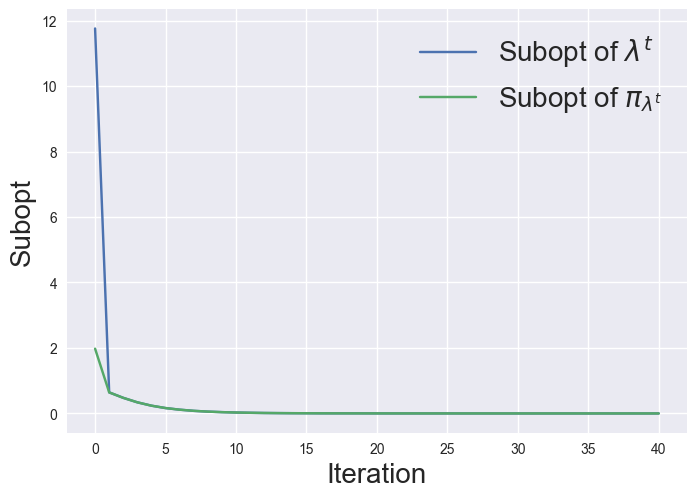

In [93]:
plot_lines([np.array(subopts), policy_subopts.flatten()], [r"Subopt of $\lambda^t$", r"Subopt of $\pi_{\lambda^t}$"], ["Iteration", "Subopt"], "figs", "subopts.pdf", show = True)

# Ex 4: Lagrangian methods [ 20 points ]

In this section we compute an optimal policy finding a saddle point of the Lagrangian $\mathcal{L}(\lambda, V)$, defined as follows

$$
\mathcal{L}(\lambda, V) = \langle \lambda, r \rangle + \langle (1 - \gamma) \mu + \gamma P^T \lambda - E^T \lambda, V \rangle .
$$

Finding a saddle point of the Lagrangian means solving the following problem:

$$ 
\mathrm{argmax}_{\lambda \geq 0} \min_{V \in \mathbb{R}^{|\mathcal{S}|}} \mathcal{L}(\lambda, V).
$$

By slide 6 in Lecture 3 it should be clear that there exists a saddle point pair $\lambda^\star, V^\star$ such that $|| V^\star ||_{\infty} \leq \frac{\max_{s,a} |r(s,a)|}{1 - \gamma}$. Therefore, we can consider looking for a saddle point over a restricted domain $\mathcal{V} = \{ V : ||V||_{\infty} \leq \frac{\max_{s,a} |r(s,a)|}{1 - \gamma} \}$:

$$ 
\mathrm{argmax}_{\lambda \geq 0} \min_{V \in \mathcal{V}} \mathcal{L}(\lambda, V).
$$

At this point we solve this problem with gradient descent ascent updates 

$$
\lambda^{k+1} \propto \lambda^k \odot \exp(\eta_{\lambda} \nabla_{\lambda} \mathcal{L}(\lambda^k, V^k)),
$$

$$
V^{k+1} = \Pi_{\mathcal{V}}[V^k - \eta_V \nabla_{V} \mathcal{L}(\lambda^k, V^k)].
$$

**Question**: 

Compute the following gradients:

$$  \nabla_{\lambda} \mathcal{L}(\lambda^k, V^k) = r + (\gamma P - E)V^k = r + \gamma PV^k - EV^k $$

$$ \nabla_{V} \mathcal{L}(\lambda^k, V^k) = (1-\gamma)\mu + \gamma P^\top\lambda^k - E^\top\lambda^k $$

**Question:**

Which of the following conditions ensure that the policy $$\pi_{\lambda^k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda^k(s,a)}$$ is $\epsilon$-suboptimal ?

(a) $$\langle \lambda^\star, r \rangle - \langle \lambda^k, r \rangle \leq \epsilon.$$
(b) $$(1 - \gamma)\langle \mu, V^\star \rangle - \langle \mu, V^k \rangle \leq \epsilon.$$
(c) $$ \mathcal{L}(\lambda^\star, V^k) - \mathcal{L}(\lambda^k, V^{\pi^{\lambda^k}}) \leq \epsilon.$$

Answer (a),(b) or (c).

**Answer**

**1. Gradient computations**

The Lagrangian is:

$$
\begin{aligned}
\mathcal{L}(\lambda, V)
&= \langle\lambda, r\rangle + \langle(1-\gamma)\mu + \gamma P^\top\lambda - E^\top\lambda,\ V\rangle \\
&= \langle\lambda, r\rangle + \langle\lambda, (\gamma P - E)V\rangle + (1-\gamma)\langle \mu, V\rangle
\end{aligned}
$$

**Gradient with respect to $\lambda$ evaluated at $\lambda^k, V^k$:**

$$\nabla_\lambda \mathcal{L}(\lambda^k, V^k) = r + (\gamma P - E)V^k = r + \gamma PV^k - EV^k$$

i.e. the vector with entries $r(s,a) + \gamma\sum_{s'}P(s'|s,a)V^k(s') - V^k(s)$ for each $(s,a)$. This is the Bellman advantage of $V^k$ under each state-action pair.

**Gradient with respect to $V$:**

$$\nabla_V \mathcal{L}(\lambda^k, V^k) = (1-\gamma)\mu + \gamma P^\top\lambda^k - E^\top\lambda^k$$

i.e. the vector with entries $(1-\gamma)\mu(s) + \gamma\sum_{s',a'}P(s|s',a')\lambda^k(s',a') - \sum_a \lambda^k(s,a)$ for each $s$. This is the discrepancy between inflow and outflow at each state under $\lambda^k$, which is zero when $\lambda^k$ is a valid occupancy measure.

**2. $\epsilon$-suboptimality**
The correct answer is **(c)**:
$$\mathcal{L}(\lambda^\star, V^k) - \mathcal{L}(\lambda^k, V^{\pi_{\lambda^k}}) \leq \epsilon.$$

# * Question [20 points]

Prove that the answer you gave at the question above implies that the policy $$\pi_{\lambda_k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda^k(s,a)}$$ is $\epsilon$-suboptimal.
*Recall:* A policy $\pi$ is $\epsilon$-suboptimal if $ (1 - \gamma)  \langle\mu , V^\star - V^{\pi} \rangle\leq \epsilon$

 **Answer**

**Claim:** If $\mathcal{L}(\lambda^\star, V^k) - \mathcal{L}(\lambda^k, V^{\pi_{\lambda^k}}) \leq \epsilon$, then $\pi_{\lambda^k}$ is $\epsilon$-suboptimal, i.e. $(1-\gamma)\langle\mu, V^\star - V^{\pi_{\lambda^k}}\rangle \leq \epsilon$.

**1. Evaluating $\mathcal{L}(\lambda^\star, V^k)$.**

Since $\lambda^\star$ is dual optimal, it satisfies the constraint $(E^\top - \gamma P^\top)\lambda^\star = (1-\gamma)\mu$, which gives $(1-\gamma)\mu + \gamma P^\top\lambda^\star - E^\top\lambda^\star = 0$. Therefore, for any $V$:
$$\mathcal{L}(\lambda^\star, V) = \langle\lambda^\star, r\rangle + \langle 0,\ V\rangle = \langle\lambda^\star, r\rangle.$$
By strong duality (primal-dual identity): $\langle\lambda^\star, r\rangle = (1-\gamma)\langle\mu, V^\star\rangle$. Hence:
$$\mathcal{L}(\lambda^\star, V^k) = \langle\lambda^\star, r\rangle = (1-\gamma)\langle\mu, V^\star\rangle. \tag{1}$$

**2. Lower bounding $\mathcal{L}(\lambda^k, V^{\pi_{\lambda^k}})$.**

We compute:
$$\mathcal{L}(\lambda^k, V^{\pi_{\lambda^k}}) = \langle\lambda^k, r\rangle + \langle(1-\gamma)\mu + \gamma P^\top\lambda^k - E^\top\lambda^k,\ V^{\pi_{\lambda^k}}\rangle$$

Since $\lambda^k$ is a valid occupancy measure (because it satisfies $(E^\top - \gamma P^\top)\lambda^k = (1-\gamma)\mu$ exactly when the inner minimization is exact), the second term vanishes and:
$$\mathcal{L}(\lambda^k, V^{\pi_{\lambda^k}}) = \langle\lambda^k, r\rangle = (1-\gamma)\langle\mu, V^{\pi_{\lambda^k}}\rangle, \tag{2}$$
where the last equality uses the identity $(1-\gamma)V^\pi(\mu) = \langle\lambda^\pi, r\rangle$ (Slide 18) and the fact that $\lambda^k = \lambda^{\pi_{\lambda^k}}$ when $\lambda^k$ is a valid occupancy measure.

**3. Combining.**

We substitute (1) and (2) into the hypothesis:
$$\epsilon \geq \mathcal{L}(\lambda^\star, V^k) - \mathcal{L}(\lambda^k, V^{\pi_{\lambda^k}}) = (1-\gamma)\langle\mu, V^\star\rangle - (1-\gamma)\langle\mu, V^{\pi_{\lambda^k}}\rangle = (1-\gamma)\langle\mu, V^\star - V^{\pi_{\lambda^k}}\rangle.$$

Which is exactly the definition of $\epsilon$-suboptimality. $\square$

**Why (a) and (b) are insufficient (CHECK IF IT MAKES SENSE)**

Condition (a) bounds the dual objective gap but does not control the policy value directly and $\lambda^\star$ may not be equal to $\lambda^{\pi_{\lambda^k}}$, so $\langle\lambda^\star, r\rangle - \langle\lambda^k, r\rangle \leq \epsilon$ does not imply $(1-\gamma)\langle\mu, V^\star - V^{\pi_{\lambda^k}}\rangle \leq \epsilon$.

Condition (b) bounds $(1-\gamma)\langle\mu, V^\star - V^k\rangle$ but $V^k$ is the iterate of the primal variable, not the value function of the extracted policy $\pi_{\lambda^k}$.

Condition (c) is the tightest and produces a **joint** bound on the saddle-point gap that simultaneously controls both the primal suboptimality and the dual feasibility. Together those two yield the policy suboptimality.


**NB**: This holds **exactly** when the inner minimization is exact, and **approximately** otherwise.